# Önleyici Bakım - Enerji Anomalisi Tespiti
Amaç:
  - Bu proje, bir makinedeki sensör ve enerji tüketimi verilerini kullanarak anormal çalışma davranışlarını tespit etmeyi amaçlar.
  - Bu anormallikler henüz bir arıza oluşturmamış olsa bile ekipmanın verimsiz veya olağan dışı çalıştığını gösterebilir.
  - Bu nedenle bu proje gerçek anlamda önleyici bakım senaryosunun karşılığıdır.

Veri seti:
  - Sentetik veri seti özellikleri:
    - vibration_rms
    - temperature
    - current
    - load
    - energy_consumption (enerji tüketimi)

Veri setinin %95 normal çalışma, %5 anormal çalışma davranışı içerir ancak veriler etiketsiz olarak modele verilir.

Kullanılacak Yöntem:
Isolation forest: anomali tespit modeli
  - normal davranıştan sapan örnekleri ayırmada çok başarılıdır.

Akış şeması:
  1. sentetik veri üretme ve basit analiz
  2. Modelin eğitilmesi ve değerlendirilmesi


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [2]:
# sentetik veri üretimi
np.random.seed(42) # tekrar üretilmesi için sabit tohum tanımlanır.
n_normal = 950
n_anomaly = 50

In [3]:
# normal çalışma verisi (verimli ve stabil)
vib_norm = np.random.normal(1.5,0.3,n_normal)
temp_norm = np.random.normal(65, 4, n_normal)
cur_norm = np.random.normal(8,1, n_normal)
load_norm = np.random.normal(55, 8, n_normal)
energy_norm = np.random.normal(120, 12, n_normal)

In [4]:
# anormal çalışma ama henüz arıza yok
vib_an = np.random.normal(2.3, 0.3, n_anomaly)
temp_an = np.random.normal(78, 6, n_anomaly)
cur_an = np.random.normal(12, 1.4, n_anomaly)
load_an = np.random.normal(78, 10, n_anomaly)
energy_an = np.random.normal(185, 20, n_anomaly)

In [5]:
# birleştirme
vibration = np.concatenate([vib_norm, vib_an])
temperature = np.concatenate([temp_norm, temp_an])
current = np.concatenate([cur_norm, cur_an])
load = np.concatenate([load_norm, load_an])
energy = np.concatenate([energy_norm, energy_an])

In [6]:
# dataframe oluşturma
df = pd.DataFrame({
    'vibration_rms': vibration,
    'temperature': temperature,
    'current': current,
    'load': load,
    'energy_consumption': energy
})

In [7]:
df.head()

,vibration_rms,temperature,current,load,energy_consumption
0,1.649014,64.035056,8.696954,50.613850,103.337489
1,1.458521,66.408222,7.666181,61.666671,100.796747
2,1.694307,59.993842,9.173125,46.161098,105.392608
3,1.956909,70.775058,8.369642,56.764331,121.913550
4,1.429754,64.671395,7.892698,64.743673,109.286550


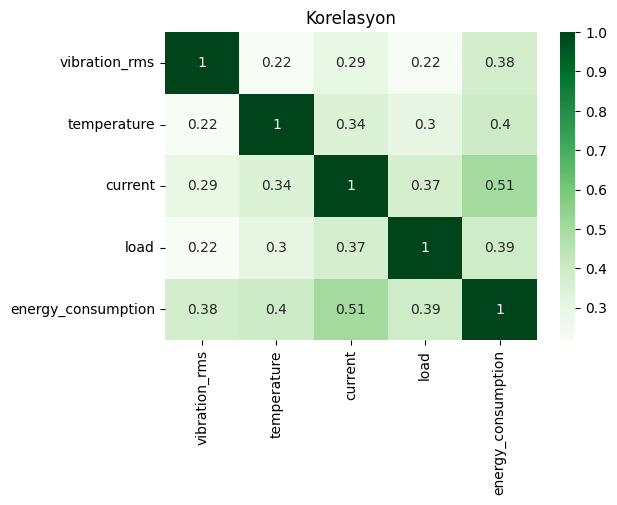

In [8]:
# korelasyon matrisi
plt.figure(figsize = (6,4))
sns.heatmap(df.corr(), annot = True, cmap = "Greens")
plt.title("Korelasyon")
plt.show()

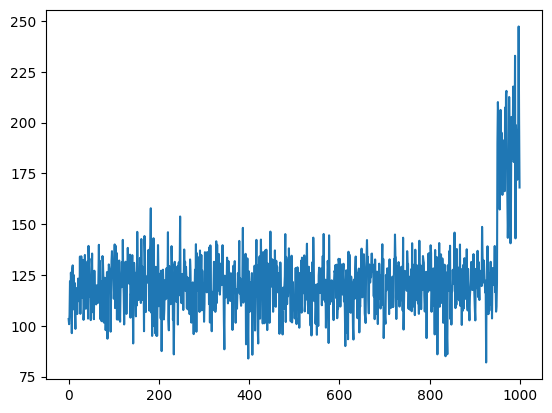

In [9]:
plt.plot(df["energy_consumption"])

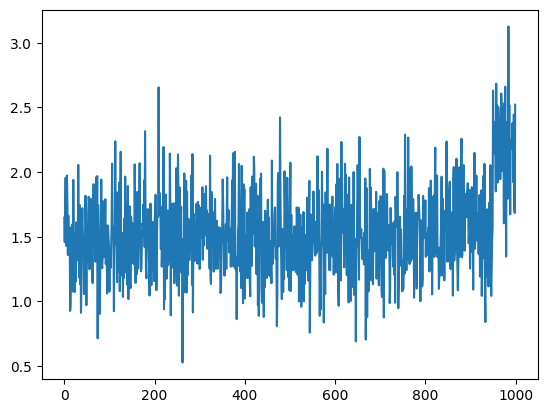

In [10]:
plt.plot(df["vibration_rms"])

In [11]:
# modelin eğitilmesi ve sonuçların değerlendirilmesi

In [12]:
#isolation forest modeli
model = IsolationForest(
    n_estimators = 100, # ağaç sayısı
    contamination = 0.05, # veri içerisinde %5 lik farklılıkları anomali olarak işaretler yani anomali olarak kabul eder
)

In [13]:
model.fit(df) # etiket yok, tamamen unsupervised learning yani gözetimsiz öğrenme

IsolationForest(contamination=0.05)

In [14]:
# anomali tespiti bu aşamada veri setinde bulunan normal olmayan davranışların tespiti eğitilmiş isolation forest ile gerçekleştirelecektir.
df["anomaly"] = model.predict(df) # -1 = anomaly, 1 = normal
df

,vibration_rms,temperature,current,load,energy_consumption,anomaly
0,1.649014,64.035056,8.696954,50.613850,103.337489,1
1,1.458521,66.408222,7.666181,61.666671,100.796747,1
2,1.694307,59.993842,9.173125,46.161098,105.392608,1
3,1.956909,70.775058,8.369642,56.764331,121.913550,1
4,1.429754,64.671395,7.892698,64.743673,109.286550,1
...,...,...,...,...,...,...
995,1.920798,81.185854,11.986217,88.400618,184.020699,-1
996,2.445855,64.930732,9.636093,70.602288,199.228212,-1
997,1.715188,74.823198,10.431934,64.653894,247.258204,-1
998,1.684893,74.628947,12.939276,74.143274,201.160724,-1


In [15]:
# 1 = anomaly yapalım
df["anomaly"] = df["anomaly"].map({1:0, -1:1})

In [16]:
df["anomaly"].value_counts()

,count
anomaly,
0,950
1,50


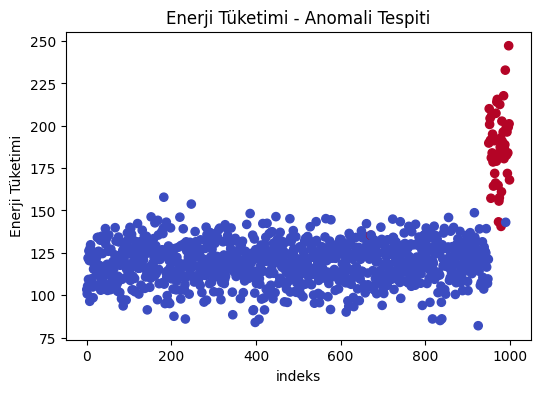

In [17]:
# anomalilerin görselleştirilmesi
plt.figure(figsize = (6,4))
plt.scatter(df.index, df["energy_consumption"], c = df["anomaly"], cmap="coolwarm", s = 35)
plt.title("Enerji Tüketimi - Anomali Tespiti")
plt.xlabel("indeks")
plt.ylabel("Enerji Tüketimi")
plt.show()